  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_Date Rating   Duration  \
0    August 14, 2020  TV-MA  4 Seasons   
1  December 23, 2016  TV-MA     93 min   
2  December 20, 2018      R     78 min   
3  November 16, 2017  PG-13     80 min   
4    January 1, 2020  PG-13    123 min   

                               

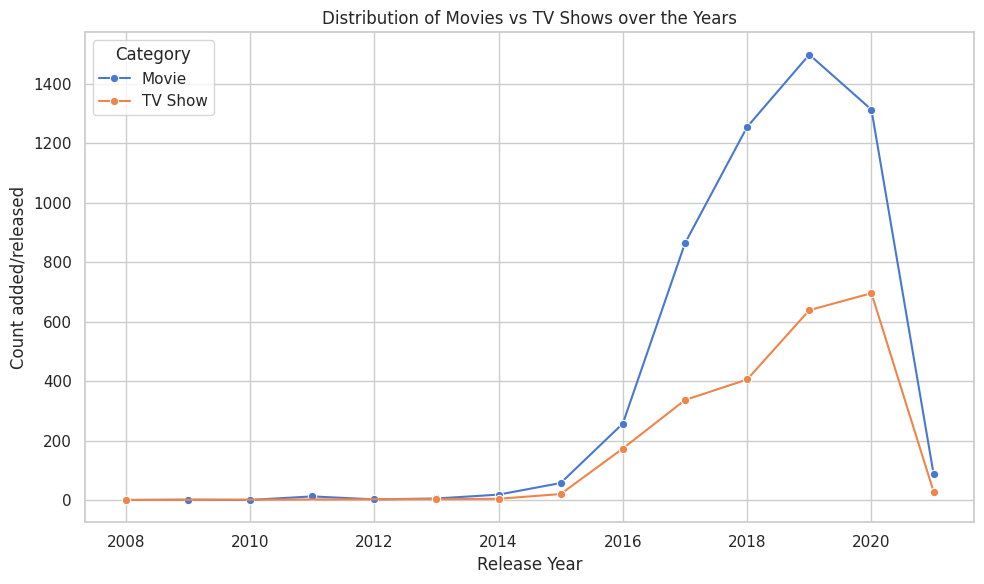

Loaded data, computed yearly counts, and displayed the plot.


In [15]:
# Load the Netflix dataset, inspect, and plot Movies vs TV Shows over years
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV with provided encoding
netflix_df = pd.read_csv('Netflix Dataset.csv', encoding='utf-8')

# Basic cleaning: parse Release_Date to datetime and extract year
netflix_df['Release_Year'] = pd.to_datetime(netflix_df['Release_Date'], errors='coerce').dt.year

# Keep only valid years and types
counts_by_year_type = (
    netflix_df.dropna(subset=['Release_Year', 'Category'])
    .groupby(['Release_Year', 'Category'])
    .size()
    .reset_index(name='Count')
)

# Show head of the raw and aggregated data for quick verification
print(netflix_df.head())
print(counts_by_year_type.head())

# Plot distribution over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=counts_by_year_type.sort_values('Release_Year'), x='Release_Year', y='Count', hue='Category', marker='o')
plt.title('Distribution of Movies vs TV Shows over the Years')
plt.xlabel('Release Year')
plt.ylabel('Count added/released')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

print('Loaded data, computed yearly counts, and displayed the plot.')

   Title                   Genre  Release_Year
0     3%  International TV Shows        2020.0
0     3%               TV Dramas        2020.0
0     3%     TV Sci-Fi & Fantasy        2020.0
1  07:19                  Dramas        2016.0
1  07:19    International Movies        2016.0
   Release_Year                     Genre  Count
0        2008.0                    Dramas      1
1        2008.0        Independent Movies      1
2        2009.0                    Dramas      1
3        2009.0      International Movies      1
4        2011.0  Children & Family Movies      1


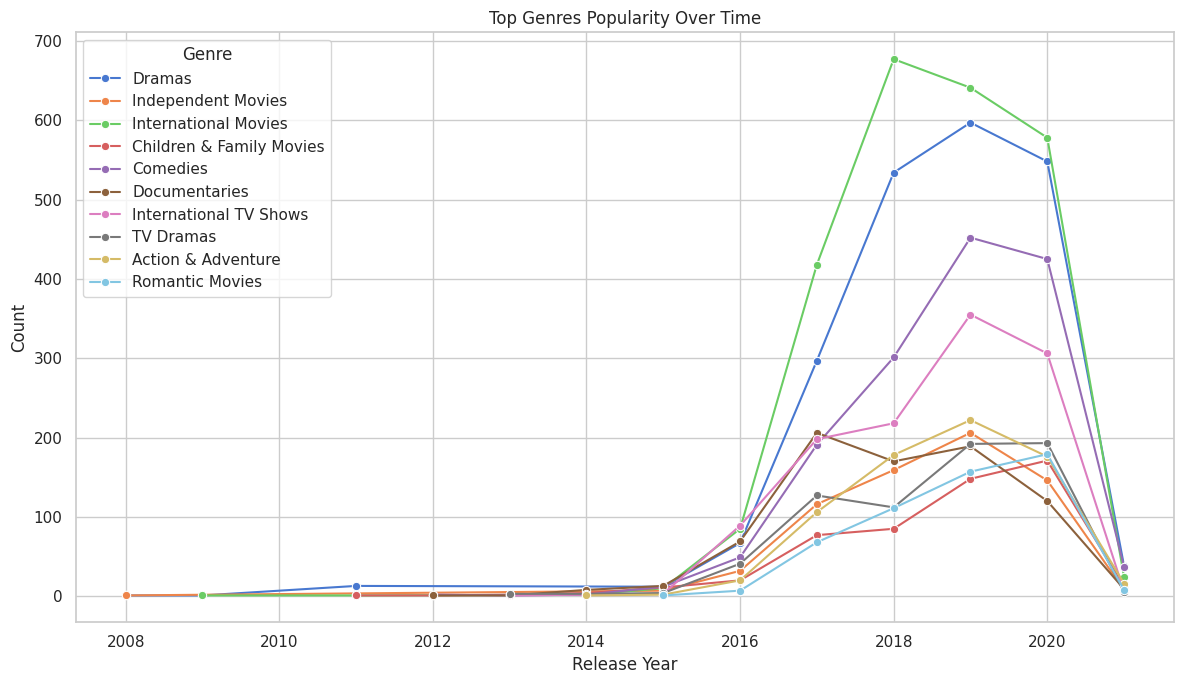

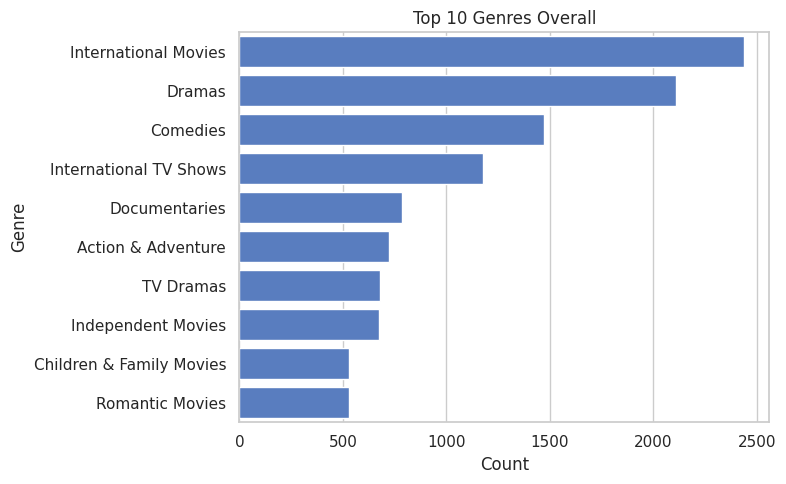

Parsed genres, computed yearly trends for top genres, and displayed two plots.


In [16]:
# Parse genres from the Type column (comma-separated) and analyze frequency over years
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume netflix_df already loaded from previous step; if not, load it
try:
    netflix_df
except NameError:
    netflix_df = pd.read_csv('Netflix Dataset.csv', encoding='utf-8')
    netflix_df['Release_Year'] = pd.to_datetime(netflix_df['Release_Date'], errors='coerce').dt.year

# Split Type (which holds genre-like categories) into individual genres
genres_expanded = (
    netflix_df.dropna(subset=['Type', 'Release_Year'])
    .assign(GenreList=lambda d: d['Type'].str.split(', '))
    .explode('GenreList')
)

# Clean genre strings
genres_expanded['Genre'] = genres_expanded['GenreList'].str.strip()

# Compute overall top genres
top_genres = genres_expanded['Genre'].value_counts().head(10).index.tolist()

# Yearly counts for top genres
year_genre_counts = (
    genres_expanded[genres_expanded['Genre'].isin(top_genres)]
    .groupby(['Release_Year', 'Genre'])
    .size()
    .reset_index(name='Count')
    .sort_values('Release_Year')
)

# Show heads
print(genres_expanded[['Title','Genre','Release_Year']].head())
print(year_genre_counts.head())

# Plot trends for top genres
plt.figure(figsize=(12, 7))
sns.lineplot(data=year_genre_counts, x='Release_Year', y='Count', hue='Genre', marker='o')
plt.title('Top Genres Popularity Over Time')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Also show bar of overall top genres
overall_counts = genres_expanded['Genre'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=overall_counts.values, y=overall_counts.index, orient='h')
plt.title('Top 10 Genres Overall')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

print('Parsed genres, computed yearly trends for top genres, and displayed two plots.')

   Title   CountryClean  Release_Year
0     3%         Brazil        2020.0
1  07:19         Mexico        2016.0
2  23:59      Singapore        2018.0
3      9  United States        2017.0
4     21  United States        2020.0
           Country  Count
0    United States   3297
1            India    990
2   United Kingdom    722
3           Canada    412
4           France    349
5            Japan    287
6            Spain    215
7      South Korea    212
8          Germany    199
9           Mexico    154
10           China    147
11       Australia    144
12           Egypt    110
13          Turkey    108
14       Hong Kong    102


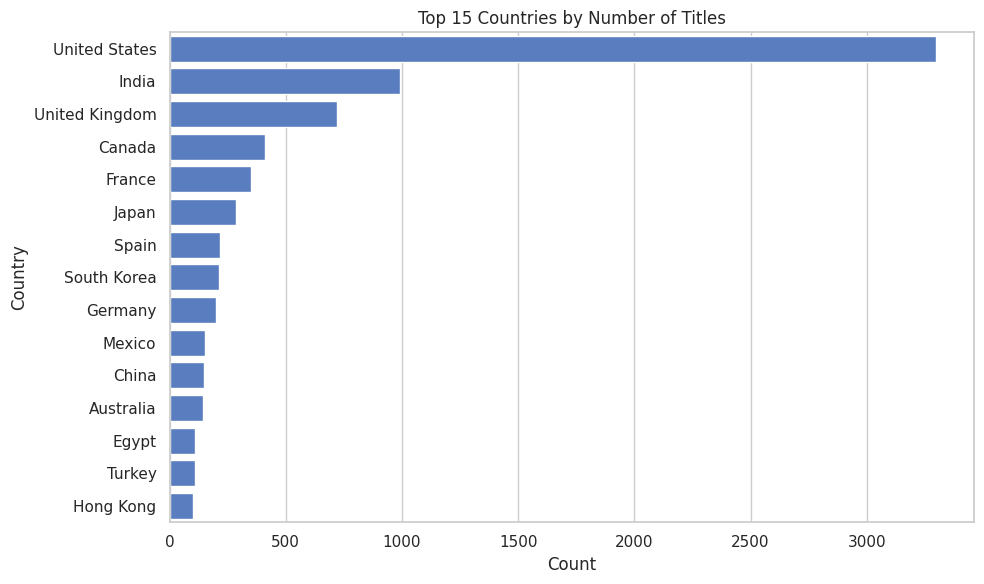

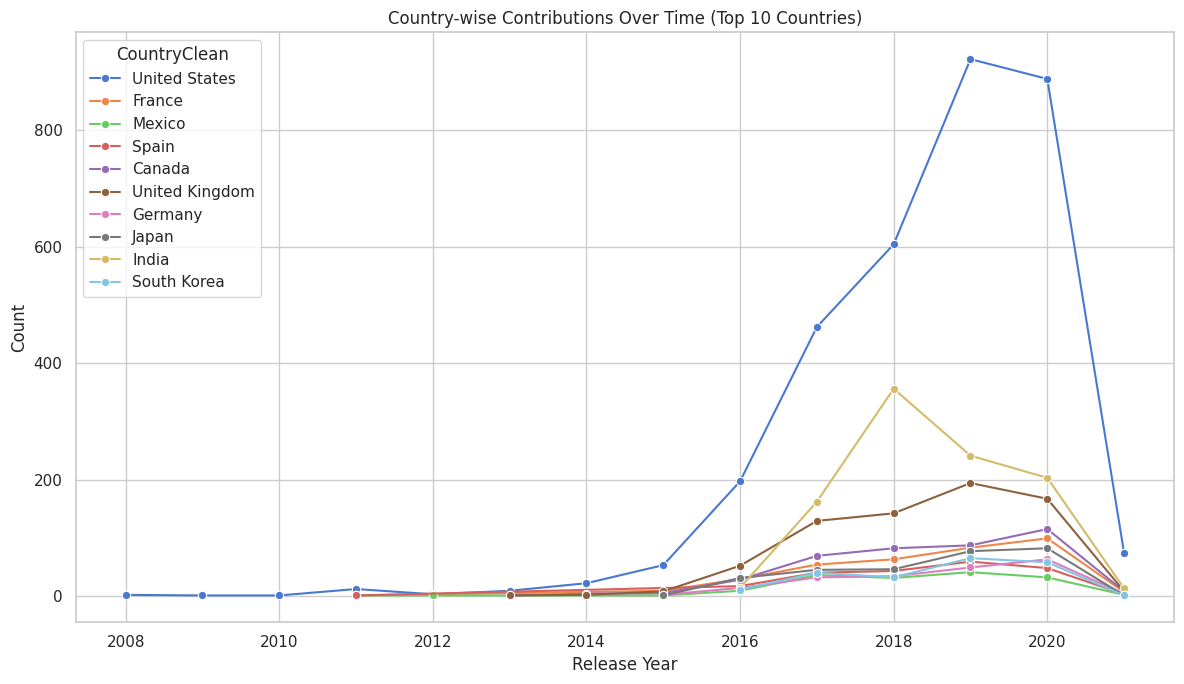

Computed country-wise totals and time trends; displayed bar and line charts.


In [17]:
# Country-wise contributions to Netflix catalog: overall and over time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dataframe present
try:
    netflix_df
except NameError:
    netflix_df = pd.read_csv('Netflix Dataset.csv', encoding='utf-8')
    netflix_df['Release_Year'] = pd.to_datetime(netflix_df['Release_Date'], errors='coerce').dt.year

# Countries column may have multiple countries; split and explode
countries_expanded = (
    netflix_df.dropna(subset=['Country'])
    .assign(CountryList=lambda d: d['Country'].str.split(', '))
    .explode('CountryList')
)

countries_expanded['CountryClean'] = countries_expanded['CountryList'].str.strip()

# Overall top countries
country_counts = countries_expanded['CountryClean'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

# Show head of exploded countries and top countries
print(countries_expanded[['Title','CountryClean','Release_Year']].head())
print(country_counts.head(15))

# Plot top 15 countries
top_n = 15
plt.figure(figsize=(10,6))
sns.barplot(data=country_counts.head(top_n), x='Count', y='Country', orient='h')
plt.title('Top ' + str(top_n) + ' Countries by Number of Titles')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# Trend over time for top 10 countries
top10 = country_counts.head(10)['Country'].tolist()
country_year = (
    countries_expanded[countries_expanded['CountryClean'].isin(top10)]
    .dropna(subset=['Release_Year'])
    .groupby(['Release_Year','CountryClean'])
    .size()
    .reset_index(name='Count')
    .sort_values('Release_Year')
)

plt.figure(figsize=(12,7))
sns.lineplot(data=country_year, x='Release_Year', y='Count', hue='CountryClean', marker='o')
plt.title('Country-wise Contributions Over Time (Top 10 Countries)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Computed country-wise totals and time trends; displayed bar and line charts.')